# Inisiasi Program

## Instalasi dan Impor Library

In [22]:
!pip install tensorflow
!pip install wordcloud
!pip install imblearn
!pip install seaborn
!pip install transformers datasets

In [31]:
# Library dasar
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# Library untuk preprocessing data
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Library untuk pretrained model
from transformers import BertTokenizer, TFBertForSequenceClassification

# Library untuk model building
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Layer, MultiHeadAttention,
    LayerNormalization, Dropout, Add, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Library untuk evaluasi model
from sklearn.metrics import classification_report, confusion_matrix

## Impor Dataset

In [5]:
# Nama file yang sudah di-upload
nama_file = 'Data.csv'

# Membaca file CSV dengan encoding yang berbeda
try:
    df = pd.read_csv(nama_file, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 decoding failed, trying latin-1...\n")
    df = pd.read_csv(nama_file, encoding='latin-1')


# Menampilkan informasi umum
print("Informasi Umum Dataset:")
df.info()

UTF-8 decoding failed, trying latin-1...

Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23644 entries, 0 to 23643
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet      23644 non-null  object
 1   sentiment  23644 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 369.6+ KB


## Impor Pre-trained Model

In [24]:
# Tentukan model yang akan digunakan (IndoBERT base, case-unspecific)
model_name = "indobenchmark/indobert-base-p1"

# 1. Muat Tokenizer
tokenizer = BertTokenizer.from_pretrained(model_name)

# 2. Muat Model (TF = TensorFlow)
# Tentukan jumlah label (positif/negatif = 2)
model = TFBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Praproses Data

## Filter dan Rename Data Records

In [6]:
# Hanya ambil sentimen positif dan negatif (tidak mengambil netral)
df = df[df['sentiment'].isin([1, 2])].reset_index(drop=True)

# Rename sentimen angka menjadi teks
df['sentiment'] = df['sentiment'].map({1: 'Positif', 2: 'Negatif'})

# Tampilkan contoh dataset yang telah diubah
df.head()

,Tweet,sentiment
0,Ketahui informasi pembagian #PPKM di wilayah J...,Positif
1,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,Positif
2,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",Positif
3,Ketahui informasi pembagian #PPKM di wilayah J...,Positif
4,Kementerian Agama menerbitkan Surat Edaran Nom...,Positif


## Visualisasi Distribusi Kata pada Raw Data

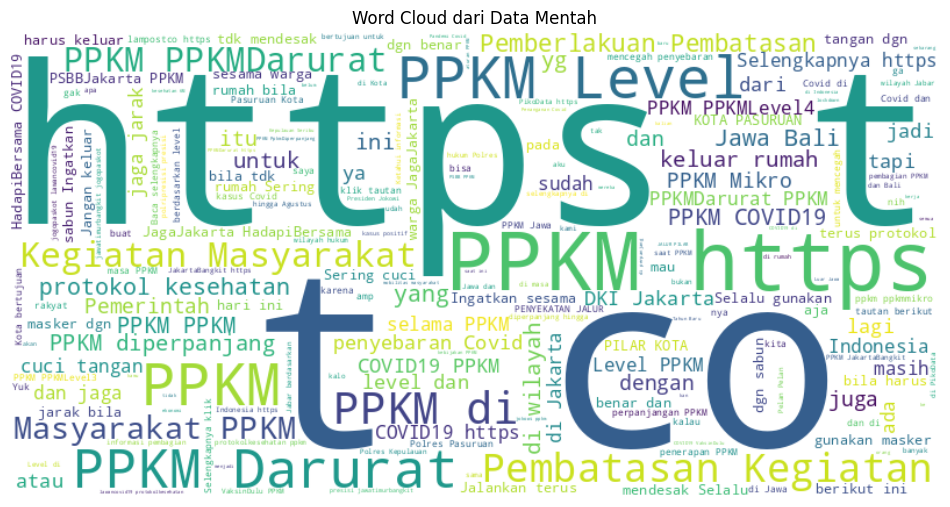

In [9]:
# Gabungkan semua teks mentah menjadi satu string besar
raw_text = " ".join(df['Tweet'].astype(str))

# Gunakan wordcloud untuk visualisasi distribusi kata
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

# Plot wordcloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Data Mentah')
plt.show()

## Data Cleaning

### Stopword List

Berikut adalah list dari stopword yang kurang akan berguna dalam data training, sehingga sebaiknya dibersihkan dengan cara dihapus dari dataset.

In [10]:
stopword_list = [
    'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa',
    'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti',
    'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan', 'berkenaan', 'berlainan', 'berlalu', 'berlangsung', 'berlebihan', 'bermacam', 'bermacam-macam', 'bermaksud', 'bermula', 'bersama', 'bersama-sama', 'bersiap', 'bersiap-siap', 'bertanya', 'bertanya-tanya', 'berturut',
    'berturut-turut', 'bertutur', 'berujar', 'berupa', 'besar', 'betul', 'betulkah', 'biasa', 'biasanya', 'bila', 'bilakah', 'bisa', 'bisakah', 'boleh', 'bolehkah', 'bolehlah', 'buat', 'bukanlah', 'bukannya', 'bulan', 'bung', 'cara', 'caranya', 'cukup', 'cukupkah', 'cukuplah', 'cuma', 'dahulu', 'dalam', 'dan', 'dapat', 'dari', 'daripada', 'datang', 'dekat', 'demi', 'demikian', 'demikianlah', 'dengan',
    'depan', 'di', 'dia', 'diakhiri', 'diakhirinya', 'dialah', 'diantara', 'diantaranya', 'diberi', 'diberikan', 'diberikannya', 'dibuat', 'dibuatnya', 'didapat', 'didatangkan', 'digunakan', 'diibaratkan', 'diibaratkannya', 'diingat', 'diingatkan', 'diinginkan', 'dijawab', 'dijelaskan', 'dijelaskannya', 'dikarenakan', 'dikatakan', 'dikatakannya', 'dikerjakan', 'diketahui', 'diketahuinya', 'dikiranya',
    'dilakukan', 'dilalui', 'dilihat', 'dimaksud', 'dimaksudkan', 'dimaksudkannya', 'dimaksudnya', 'diminta', 'dimintai', 'dimisalkan', 'dimulai', 'dimulailah', 'dimulainya', 'dimungkinkan', 'dini', 'dipastikan', 'diperbuat', 'diperbuatnya', 'dipergunakan', 'diperkirakan', 'diperlihatkan', 'diperlukan', 'diperlukannya', 'dipersoalkan', 'dipertanyakan', 'dipunyai', 'diri', 'dirinya',
    'disampaikan', 'disebut', 'disebutkan', 'disebutkannya', 'disini', 'disinilah', 'ditambahkan', 'ditandaskan', 'ditanya', 'ditanyai', 'ditanyakan', 'ditegaskan', 'ditujukan', 'ditunjuk', 'ditunjuki', 'ditunjukkan', 'ditunjukkannya', 'dituntun', 'diturunkan', 'diturunkan', 'dituturkan', 'dituturkannya', 'diucapkan', 'diucapkannya', 'diungkapkan', 'dong', 'dua', 'dulu', 'enggak',
    'engkaulah', 'entah', 'entahlah', 'guna', 'gunakan', 'hal', 'hampir', 'hanya', 'hanyalah', 'hari', 'harus', 'haruslah', 'harusnya', 'hendak', 'hendaklah', 'hendaknya', 'hingga', 'ia', 'ialah', 'ibarat', 'ibaratnya', 'ibu', 'ikut', 'ingat', 'ingat-ingat', 'ingin', 'inginkah', 'inginkan', 'ini', 'inikah', 'inilah', 'itu', 'itukah', 'itulah', 'jadi', 'jadilah', 'jadinya', 'jauh', 'jawab', 'jawaban',
    'jawabnya', 'jelas', 'jelaskan', 'jelaslah', 'jelasnya', 'jika', 'jikalau', 'juga', 'jumlah', 'jumlahnya', 'justru', 'kala', 'kalau', 'kalaulah', 'kalaupun', 'kali', 'kalian', 'kami', 'kamilah', 'kamu', 'kamulah', 'kan', 'kapan', 'kapankah', 'kapanpun', 'karena', 'karenanya', 'kasus', 'kata', 'katakan', 'katakanlah', 'katanya', 'ke', 'keadaan', 'kebetulan', 'kecil', 'kedua', 'keduanya',
    'keinginan', 'kelak', 'kelima', 'kelihatan', 'kelihatannya', 'keliru', 'kembali', 'kemudian', 'kemungkinan', 'kemungkinannya', 'kenapa', 'kepada', 'kepadanya', 'kesejahteraan', 'keseluruhan', 'keseluruhannya', 'keterlaluan', 'ketika', 'khususnya', 'kini', 'kinilah', 'kira', 'kira-kira', 'kiranya', 'kita', 'kitalah', 'kok', 'kurang', 'lagi', 'lagian', 'lah', 'lain', 'lainnya', 'lalu',
    'lama', 'lamanya', 'lanjut', 'lanjutnya', 'lebih', 'lewat', 'lima', 'luar', 'macam', 'maka', 'makanya', 'makin', 'malah', 'malahan', 'mampu', 'mampukah', 'mana', 'manakala', 'manalagi', 'masa', 'masalah', 'masalahnya', 'masih', 'masihkah', 'masing', 'masing-masing', 'mau', 'maupun', 'melainkan', 'melakukan', 'melalui', 'melihat', 'melihatnya', 'memang', 'memastikan', 'memberi',
    'memberikan', 'membuat', 'memerlukan', 'memihak', 'meminta', 'memintakan', 'memisalkan', 'memperbuat', 'mempergunakan', 'memperkirakan', 'memperlihatkan', 'mempersiapkan', 'mempersoalkan', 'mempertanyakan', 'mempunyai', 'memulai', 'menjadi', 'menuju', 'menurut', 'menyeluruh', 'menyiapkan', 'merasa', 'mereka', 'merekalah', 'merupakan', 'meski', 'meskipun', 'meyakini', 'meyakinkan', 'minta',
    'mirip', 'misal', 'misalkan', 'misalnya', 'mula', 'mulai', 'mulailah', 'mulanya', 'mungkin', 'mungkinkah', 'nah', 'naik', 'namun', 'nanti', 'nantinya', 'nyaris', 'nyatanya', 'oleh', 'olehnya', 'pada', 'padahal', 'padanya', 'pak', 'paling', 'panjang', 'pantas', 'para', 'pasti', 'pastilah', 'penting', 'pentingnya', 'per', 'percuma', 'perlu', 'perlukah', 'perlunya', 'pernah', 'persoalan',
    'pertama', 'pertama-tama', 'pertanyaan', 'pertanyakan', 'pihak', 'pihaknya', 'pukul', 'pula', 'pun', 'punya', 'rasa', 'rasanya', 'rata', 'rupanya', 'saat', 'saatnya', 'saja', 'sajalah', 'saling', 'sama', 'sama-sama', 'sambil', 'sampai', 'sampai-sampai', 'sana', 'sangat', 'sangatlah', 'satu', 'saya', 'sayalah', 'se', 'sebab', 'sebabnya', 'sebagai', 'sebagaimana', 'sebagainya', 'sebagian',
    'sebaik', 'sebaik-baiknya', 'sebaiknya', 'sebaliknya', 'sebanyak', 'sebelum', 'sebelumnya', 'sebenarnya', 'seberapa', 'sebesar', 'sebetulnya', 'sebisanya', 'sebuah', 'sebut', 'sebutlah', 'sebutnya', 'secara', 'secukupnya', 'sedang', 'sedangkan', 'sedemikian', 'sedikit', 'sedikitnya', 'seenaknya', 'segala', 'segalanya', 'segera', 'seharusnya', 'sehingga', 'seingat', 'sejak',
    'sejauh', 'sejenak', 'sejumlah', 'sekadar', 'sekadarnya', 'sekali', 'sekali-kali', 'sekalian', 'sekaligus', 'sekalipun', 'sekarang', 'sekaranglah', 'sekecil', 'seketika', 'sekiranya', 'sekitar', 'sekitarnya', 'sela', 'selain', 'selaku', 'selalu', 'selama', 'selama-lamanya', 'selamanya', 'selanjutnya', 'seluruh', 'seluruhnya', 'semacam', 'semakin', 'semampu', 'semampunya', 'semasa',
    'semasih', 'semata', 'semata-mata', 'semaunya', 'sementara', 'semisal', 'semisalnya', 'sempat', 'semua', 'semuanya', 'semula', 'sendiri', 'sendirian', 'sendirinya', 'seolah', 'seolah-olah', 'seorang', 'sepanjang', 'sepantasnya', 'sepantasnyalah', 'seperlunya', 'seperti', 'sepertinya', 'sepihak', 'sering', 'seringnya', 'serta', 'serupa', 'sesaat', 'sesampai', 'sesegera', 'sesekali',
    'seseorang', 'sesuatu', 'sesuatunya', 'sesudah', 'sesudahnya', 'setelah', 'setempat', 'setengah', 'seterusnya', 'setiap', 'setidaknya', 'setinggi', 'seusai', 'sewaktu', 'siap', 'siapa', 'siapakah', 'siapapun', 'sini', 'sinilah', 'suatu', 'sudah', 'sudahkah', 'sudahlah', 'supaya', 'tadi', 'tadinya', 'tahu', 'tahun', 'tak', 'tanpa', 'tanya', 'tanyakan', 'tanyanya', 'tapi', 'tegas', 'tegasnya',
    'telah', 'tempat', 'tengah', 'tentang', 'tentu', 'tentulah', 'tentunya', 'tepat', 'terakhir', 'terasa', 'terbanyak', 'terdahulu', 'terdapat', 'terdiri', 'terhadap', 'terhadapnya', 'teringat', 'teringat-ingat', 'terjadi', 'terjadilah', 'terjadinya', 'terkira', 'terlalu', 'terlebih', 'terlihat', 'termasuk', 'ternyata', 'tersebut', 'tersebutlah', 'tertentu', 'tertuju', 'terus', 'terutama',
    'tetap', 'tetapi', 'tiap', 'tiba', 'tiba-tiba', 'tidaklah', 'tidaknya', 'tiga', 'tinggi', 'toh', 'tunjuk', 'turut', 'tutur', 'tuturnya', 'ucap', 'ucapnya', 'ujar', 'ujarnya', 'umumnya', 'ungkap', 'ungkapnya', 'untuk', 'usah', 'usai', 'wah', 'wahai', 'waktu', 'waktunya', 'walau', 'walaupun', 'wong', 'yaitu', 'yakin', 'yakni', 'yang'
]

### Proses Data Cleaning

In [11]:
# Fungsi untuk membersihkan teks
def cleaning(text):
    text = str(text).lower()                             # Buat semua teks menjadi lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Hapus semua link
    text = re.sub(r'\@\w+|\#', '', text)                 # Hapus mention/tag dan hash dalam hashtag
    text = re.sub(r'\d+', '', text)                      # Hapus angka
    text = re.sub(r'[^a-z\s]', ' ', text)                # Hapus karakter selain huruf
    words = text.strip().split()                         # Bersihkan whitespace dan pisahkan teks menjadi kata-kata

    # Filter stopword pada dataset
    filtered_words = [
        word for word in words if word not in stopword_list
    ]

    # Return data bersih
    return " ".join(filtered_words)

# Simpan data bersih di kolom baru
df['cleaned_text'] = df['Tweet'].apply(cleaning)

# Tampilkan contoh dataset (sebagai perbandingan)
df.head()

,Tweet,sentiment,cleaned_text
0,Ketahui informasi pembagian #PPKM di wilayah J...,Positif,ketahui informasi pembagian ppkm wilayah jabar...
1,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,Positif,ibadah wilayah ppkm level berkapasitas persen ...
2,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",Positif,juru bicara satgas covid wiku adisasmito menje...
3,Ketahui informasi pembagian #PPKM di wilayah J...,Positif,ketahui informasi pembagian ppkm wilayah jabar...
4,Kementerian Agama menerbitkan Surat Edaran Nom...,Positif,kementerian agama menerbitkan surat edaran nom...


## Visualisasi Distribusi Kata pada Clean Data

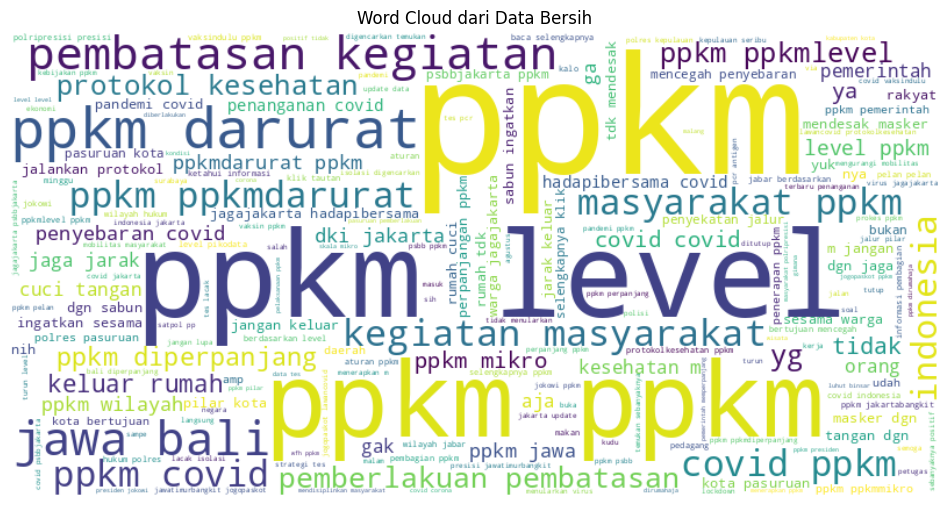

In [12]:
# Gabungkan semua teks mentah menjadi satu string besar
raw_text = " ".join(df['cleaned_text'].astype(str))

# Gunakan wordcloud untuk visualisasi distribusi kata
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

# Plot wordcloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Data Bersih')
plt.show()

# Tokenisasi, Sequencing, dan Pembagian Data

## Tokenisasi dan Padding Data

In [13]:
vocab_size = 20000    # vocab size -> semakin banyak akan membebani model,
                      #               tetapi membantu akurasi (terkait OOV ratio)

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Penentuan max length untuk tiap sequence guna mengoptimasi penilaian model
lengths = [len(s) for s in sequences]
maxlen = int(np.mean(lengths))

# Aplikasi max length pada sequence yang telah di-padding
padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post')

# Hitung total token dan rasio dari OOV token
total_tokens = sum(len(seq) for seq in sequences)
oov_tokens = sum(seq.count(1) for seq in sequences)  # index 1 biasanya OOV

## Data Label Encoding

In [19]:
labels = df['sentiment'].apply(lambda x: 1 if x == 'Positif' else 0).values
labels = labels.reshape(-1, 1)

# Cek distribusi label
unique, counts = np.unique(labels, return_counts=True)

# Jika data tidak seimbang, lakukan oversampling pada kelas minoritas
ros = RandomOverSampler(random_state=42)
x_bal, y_bal = ros.fit_resample(padded_sequences, labels)

## Pembagian Dataset

In [25]:
# Bagi data menjadi data train (80%) dan data sisa (20%)
X_train, X_rem, y_train, y_rem = train_test_split(
    x_bal,
    y_bal,
    train_size=0.8,
    random_state=42,
    stratify=y_bal
)

# Bagi data sisa (20%) menjadi 2 bagian untuk test (10%) dan val (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem,
    y_rem,
    test_size=0.5,
    random_state=42,
    stratify=y_rem
)

# Hitung weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train.flatten()),
    y=y_train.flatten()
)

# Ubah weight menjadi dictionary
class_weights_dict = dict(enumerate(class_weights))

# --- Verifikasi Hasil ---
print("Pra-pemrosesan Lanjutan Selesai.")
print(f"Bentuk data training: X={X_train.shape}, y={y_train.shape}")
print(f"Bentuk data validasi: X={X_val.shape}, y={y_val.shape}")
print(f"Bentuk data tes     : X={X_test.shape}, y={y_test.shape}")
print(f"OOV ratio           : {oov_tokens / total_tokens:.2%}")

Pra-pemrosesan Lanjutan Selesai.
Bentuk data training: X=(28329, 14), y=(28329,)
Bentuk data validasi: X=(3541, 14), y=(3541,)
Bentuk data tes     : X=(3542, 14), y=(3542,)
OOV ratio           : 4.15%


# Pembagunan Model

## Buat model dengan arsitektur Transformer

In [30]:
# --- A. Positional Encoding (Tidak berubah) ---
def get_positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(positions * div_term)
    pe[:, 1::2] = np.cos(positions * div_term)
    return tf.cast(pe[np.newaxis, ...], dtype=tf.float32)

# --- B. Fungsi Helper Masking (Hanya Padding Mask) ---
def create_padding_mask_op(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

# --- C. Blok Encoder Layer (Tidak berubah) ---
class TransformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerEncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(key_dim=d_model, num_heads=num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training, mask):
        attn_output = self.mha(query=x, value=x, key=x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # Add & Norm

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # Add & Norm
        return out2

# --- Konfigurasi Hyperparameter (Sama) ---
num_layers = 2
d_model = 128
dff = 512
num_heads = 4
dropout_rate = 0.1

# --- Input Layer (Hanya 1 input) ---
encoder_inputs = Input(shape=(maxlen,), name='encoder_input')

# --- Masking (Hanya Padding Mask) ---
enc_padding_mask = tf.keras.layers.Lambda(
    create_padding_mask_op, name='enc_padding_mask'
)(encoder_inputs)

# --- Embedding & Positional Encoding (Hanya untuk Encoder) ---
embedding_layer = Embedding(vocab_size, d_model, name='embedding_layer')

pos_encoding_enc = get_positional_encoding(maxlen, d_model)

enc_emb = embedding_layer(encoder_inputs)
enc_emb = tf.keras.layers.Lambda(lambda x: x * tf.math.sqrt(tf.cast(d_model, tf.float32)))(enc_emb)
enc_emb = tf.keras.layers.Add()([enc_emb, pos_encoding_enc[:, :maxlen, :]])
enc_emb = Dropout(dropout_rate)(enc_emb)

# --- ENCODER ---
# Tumpukan Encoder (Sama)
x = enc_emb
for i in range(num_layers):
    x = TransformerEncoderLayer(d_model, num_heads, dff, dropout_rate)(
        x, training=True, mask=enc_padding_mask
    )
encoder_output = x

# 1. Gunakan Global Average Pooling untuk merangkum seluruh kalimat
x = GlobalAveragePooling1D(name='pooling_layer')(encoder_output)

# 2. Tambahkan Dropout untuk regularisasi
x = Dropout(dropout_rate)(x)

# 3. Lapisan Dense terakhir untuk klasifikasi
# Gunakan 1 unit dengan 'sigmoid' untuk sentimen biner (0 atau 1)
final_output = Dense(1, activation='sigmoid', name='sentiment_output')(x)

# Model sekarang hanya menerima 1 input
model = Model(inputs=encoder_inputs, outputs=final_output)

# --- Kompilasi & Summary ---
# Ganti loss menjadi 'binary_crossentropy' untuk klasifikasi biner
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 14, 128)   │  2,560,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 14, 128)   │          0 │ embedding_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (1, 14, 128)      │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (1, 14, 128)      │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_padding_mask    │ (None, 1, 1, 14)  │          0 │ encoder_input[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (1, 14, 128)      │    396,032 │ dropout_7[0][0],  │
│ (TransformerEncode… │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (1, 14, 128)      │    396,032 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_layer       │ (1, 128)          │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (1, 128)          │          0 │ pooling_layer[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (1, 1)            │        129 │ dropout_14[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,352,193 (12.79 MB)

 Trainable params: 3,352,193 (12.79 MB)

 Non-trainable params: 0 (0.00 B)

# Data Training

In [33]:
# Mendefinisikan callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',          # Metrik yang dipantau
    patience=3,                  # Berhenti jika tidak ada perbaikan selama 3 epoch
    verbose=1,
    mode='min',                  # Kita ingin meminimalkan 'val_loss'
    restore_best_weights=True    # Kembalikan bobot dari epoch terbaik
)

# Melatih model
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

print("\nTraining model Transformer selesai.")

Epoch 1/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.7026 - loss: 0.6164 - val_accuracy: 0.9230 - val_loss: 0.2110
Epoch 2/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9466 - loss: 0.1448 - val_accuracy: 0.9435 - val_loss: 0.1691
Epoch 3/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9673 - loss: 0.0942 - val_accuracy: 0.9474 - val_loss: 0.1700
Epoch 4/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9742 - loss: 0.0744 - val_accuracy: 0.9322 - val_loss: 0.2435
Epoch 5/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9779 - loss: 0.0650 - val_accuracy: 0.9545 - val_loss: 0.1819
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Training model Transformer selesai.


# Visualisasi Hasil

## Loss vs Accuracy

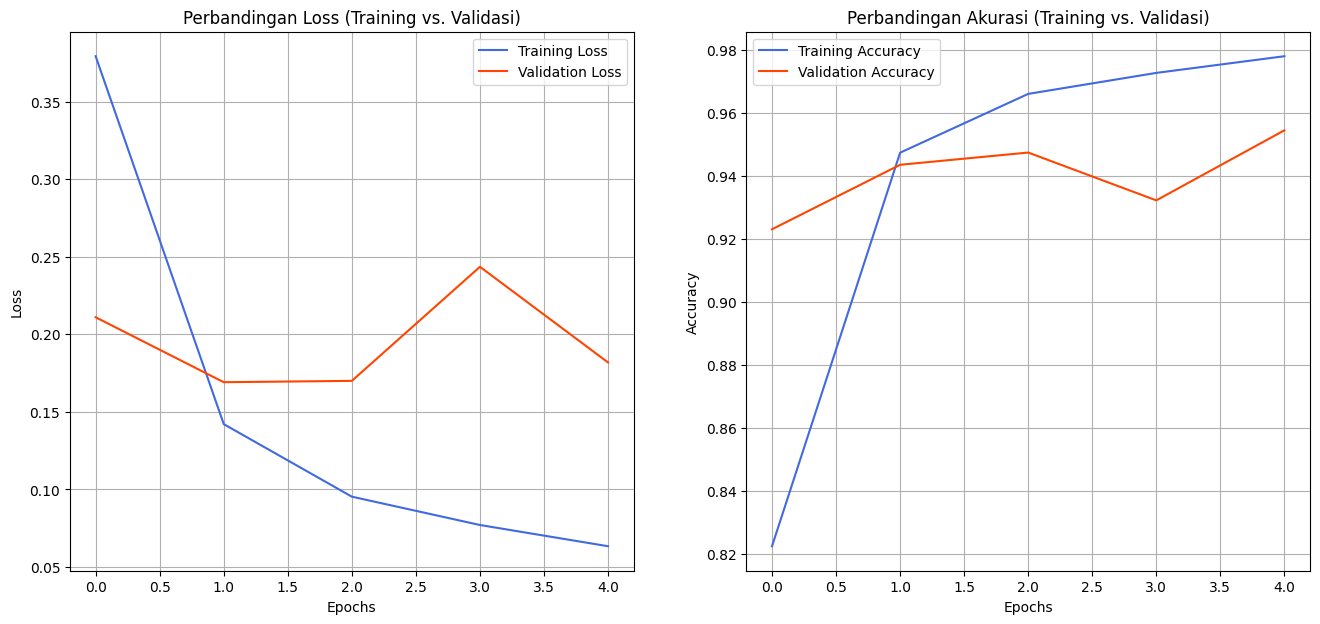

In [34]:
# Mengubah history menjadi DataFrame Pandas untuk kemudahan plotting
history_df = pd.DataFrame(history.history)

# Membuat canvas dengan 2 subplot berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Loss ---
ax1.set_title('Perbandingan Loss (Training vs. Validasi)')
ax1.plot(history_df['loss'], label='Training Loss', color='royalblue')
ax1.plot(history_df['val_loss'], label='Validation Loss', color='orangered')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Akurasi ---
ax2.set_title('Perbandingan Akurasi (Training vs. Validasi)')
ax2.plot(history_df['accuracy'], label='Training Accuracy', color='royalblue')
ax2.plot(history_df['val_accuracy'], label='Validation Accuracy', color='orangered')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()